Data generation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC

M = 2
R = np.array([4, 3])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

sigma_00 = None
mu_00 = np.array([0])
# mu_00 = np.array([5])
var_00 = np.array([1])

# Profile (0, 1)
sigma_01 = np.array([[1]])
mu_01 = np.array([-0.1])
# mu_01 = np.array([10])
var_01 = np.array([1])

# Profile (1, 0)
sigma_10 = np.array([[1, 0]])
mu_10 = np.array([-0.2, -0.3])
# mu_10 = np.array([-10, 15])
var_10 = np.array([1, 1])

# Profile (1, 1)
sigma_11 = np.array([[0, 1], [0, np.inf]])
mu_11 = np.array([0.2, 0.3, -0.1, -0.1])
# mu_11 = np.array([20, 30, 5, 10])
var_11 = np.array([1, 1, 1, 1])

sigma = [sigma_00, sigma_01, sigma_10, sigma_11]
mu = [mu_00, mu_01, mu_10, mu_11]
var = [var_00, var_01, var_10, var_11]

In [3]:
policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
pi_policies = {}
pi_pools = {}
for k, profile in enumerate(profiles):

    policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
    unzipped_temp = list(zip(*policies_temp))
    policies_ids_k = list(unzipped_temp[0])
    policies_k = list(unzipped_temp[1])
    policies_profiles[k] = deepcopy(policies_k)
    policies_ids_profiles[k] = policies_ids_k

    profile_mask = list(map(bool, profile))

    # Mask the empty arms
    for idx, pol in enumerate(policies_k):
        policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
    policies_profiles_masked[k] = policies_k

    if np.sum(profile) > 0:
        pi_pools_k, pi_policies_k = extract_pools.extract_pools(policies_k, sigma[k])
        if len(pi_pools_k.keys()) != mu[k].shape[0]:
            print(f"Profile {k}. Expected {len(pi_pools_k.keys())} pools. Received {mu[k].shape[0]} means.")
        pi_policies[k] = pi_policies_k
        # pi_pools_k has indicies that match with policies_profiles[k]
        # Need to map those indices back to all_policies
        pi_pools[k] = {}
        for x, y in pi_pools_k.items():
            y_full = [policies_profiles[k][i] for i in y]
            y_agg = [all_policies.index(i) for i in y_full]
            pi_pools[k][x] = y_agg
    else:
        pi_policies[k] = {0: 0}
        pi_pools[k] = {0: [0]}

In [4]:
def generate_data(mu, var, n_per_pol, all_policies, pi_policies, M):
    num_data = num_policies * n_per_pol
    X = np.zeros(shape=(num_data, M))
    D = np.zeros(shape=(num_data, 1), dtype='int_')
    y = np.zeros(shape=(num_data, 1))

    idx_ctr = 0
    for k, profile in enumerate(profiles):
        policies_k = policies_profiles[k]

        for idx, policy in enumerate(policies_k):
            policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

            pool_id = pi_policies[k][idx]
            mu_i = mu[k][pool_id]
            var_i = var[k][pool_id]
            y_i = np.random.normal(mu_i, var_i, size=(n_per_pol, 1))

            start_idx = idx_ctr * n_per_pol
            end_idx = (idx_ctr + 1) * n_per_pol

            X[start_idx:end_idx, ] = policy
            D[start_idx:end_idx, ] = policy_idx[0]
            y[start_idx:end_idx, ] = y_i

            idx_ctr += 1

    return X, D, y

In [5]:
num_samples_per_feature = 500

np.random.seed(721)
X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
policy_means = loss.compute_policy_means(D, y, num_policies)

In [6]:
H = np.inf
theta = 8
lamb = 1
R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True)

(0, 0) 7.088059253879942
Profile (0, 0) has 1 objects in Rashomon set
(0, 1) 7.173266237175854
Adaptive
Profile (0, 1) took 0.0014719963073730469 s adaptively
Profile (0, 1) has 2 objects in Rashomon set
(1, 0) 7.251332051904285
Adaptive
Profile (1, 0) took 0.0031042098999023438 s adaptively
Profile (1, 0) has 4 objects in Rashomon set
(1, 1) 7.508528116660401
Adaptive
Profile (1, 1) took 0.01330113410949707 s adaptively
Profile (1, 1) has 8 objects in Rashomon set
Finding feasible combinations
Min = 5.004964811182315, Max = 12.99293811345984


In [7]:
len(R_set)

27

In [8]:
anchors = AIS.build_anchor_states(R_set, R_profiles, M, R)
prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

RPS_states = AIS.raggregate_to_states((R_set, R_profiles), profiles)
score_s = AIS.make_score_s_expneg_raw(
    D=D,
    y=y,
    M=M,
    R=R,
    prof_idx_of_policy = prof_idx_of_policy,
    policies=all_policies,
    policy_means=policy_means,
    reg=lamb,
    lattice_edges=None,   # or your edges
    beta=1.0,             # exp(-loss)
    prior_logprob=lambda state: 0.0
)

In [7]:
mcmc_res = MCMC.load_mcmc_res("./toy_50000.pkl.gz")

In [16]:
log_alpha = [score_s(A) for A in anchors]
mcmc_res = MCMC.run_mcmc(score_s, RPS_states, log_alpha, n_chains=1, steps=20000, burnin=500, thin=5, seed=2, min_len=1)
# MCMC.save_mcmc_res(mcmc_res, "./toy_50000.pkl.gz")

In [8]:
log_alpha = [score_s(A) for A in anchors]
res = MCMC.run_mcmc_streaming(RPS_states, log_alpha, score_s, steps=30000, burnin=5000, thin=5,
                         out_jsonl="mcmc_run1.jsonl", progress_json="mcmc_run1_progress.json")

In [9]:
mcmc_res = MCMC.load_mcmc_res_from_jsonl("mcmc_run1.jsonl")

In [15]:
cfg = AIS.AISConfig(n_paths=500, n_levels=5, moves_per_level=5, min_len=1, seed=2)
out_500 = AIS.run_ais_state(
    anchors=R_set,          # not used by q0, but you may keep for consistency
    score_s=score_s,        # returns exp(-loss(state)) or similar
    cfg=cfg,
    RPS=RPS_states,              # your Rashomon partitions as a list of State
    R_per=R,  # levels per arm (includes control)
    eps1=0.05, eps2=0.25
)

In [9]:
cfg = AIS.AISConfig(n_paths=500, n_levels=5, moves_per_level=5, min_len=1, seed=2)
out_500 = AIS.run_ais_state_streaming(
    anchors=R_set,          # not used by q0, but you may keep for consistency
    score_s=score_s,        # returns exp(-loss(state)) or similar
    cfg=cfg,
    RPS=RPS_states,              # your Rashomon partitions as a list of State
    R_per=R,  # levels per arm (includes control)
    eps1=0.05, eps2=0.25
)

In [16]:
mu_hat = AIS.estimate_policy_means_from_ais(
    ais_out=out_500,                 # from your run_ais_state
    all_policies=all_policies,
    policy_means=policy_means,
    prof_idx_of_policy=prof_idx_of_policy,
    lattice_edges=None,                  # or the hasse edges if you use them
    R_per = R,
    M=M
)

In [11]:
# find the true partition in MCMC samples
target_by_profile = {
    0: ((0,0), sigma_00),
    1: ((0,1), sigma_01),
    2: ((1,0), sigma_10),
    3: ((1,1), sigma_11)
}

true_sample = MCMC.find_states_matching_targets(mcmc_res,R,M,target_by_profile)
print(true_sample["fraction"])
# find the RPS states in MCMC samples
RPS_post = []
for partition in RPS_states:
    target_by_profile = {
        0: ((0,0), partition[0].B),
        1: ((0,1), partition[1].B),
        2: ((1,0), partition[2].B),
        3: ((1,1), partition[3].B)
    }
    true_sample = MCMC.find_states_matching_targets(mcmc_res,R,M,target_by_profile)
    RPS_post.append(true_sample["fraction"])
    
normalized_RPS_post = [i / sum(RPS_post) for i in RPS_post]

NameError: name 'mcmc_res' is not defined

In [12]:
# calculate the exact posterior of RPS states
RPS_post_exact = []

for partition in RPS_states:
    RPS_post_exact.append(score_s(partition))

normalized_RPS_post_exact = [i / sum(RPS_post_exact) for i in RPS_post_exact]

In [43]:
# Enumerate all states and keep score
from rashomon import AIS
losses = AIS.enumerate_all_states_and_losses(
    profiles=profiles,
    R=R,
    M=M,
    policies=all_policies,
    policy_means=policy_means,
    prof_idx_of_policy=prof_idx_of_policy,
    D=D, y=y,
    reg=lamb, normalize=0,
    lattice_edges=None,
    max_states=None  # or an integer cap to safeguard
)

In [14]:
sig = [AIS.state_signature(i[0]) for i in losses]

In [15]:
true_posterior = [np.exp(-i[1]) for i in losses]
norm_true_post = [i/sum(true_posterior) for i in true_posterior]

In [16]:
true_post = []
RPS_test = []
for partition in RPS_states:
    signature = AIS.state_signature(partition)
    idx = sig.index(signature)
    RPS_test.append(true_posterior[idx])
    true_post.append(norm_true_post[idx])

In [17]:
RPS_test_norm = [i/sum(RPS_test) for i in RPS_test]

In [62]:
pd.DataFrame({'RPS_estimates_exact':normalized_RPS_post_exact, 'MCMC estimates': normalized_RPS_post, 'ture posterior': true_post, 'RPS test': RPS_test_norm})

,RPS_estimates_exact,MCMC estimates,ture posterior,RPS test
0,0.173479,0.175766,0.165015,0.173479
1,0.065350,0.061274,0.062162,0.065350
2,0.064414,0.059896,0.061272,0.064414
3,0.063820,0.070285,0.060706,0.063820
4,0.024053,0.020460,0.022879,0.024053
5,0.008849,0.007527,0.008418,0.008849
6,0.008719,0.008269,0.008293,0.008719
7,0.064248,0.063925,0.061113,0.064248
8,0.024202,0.023852,0.023021,0.024202
9,0.023856,0.024382,0.022692,0.023856


(0.007526767730308492, 0.1757659281246687)

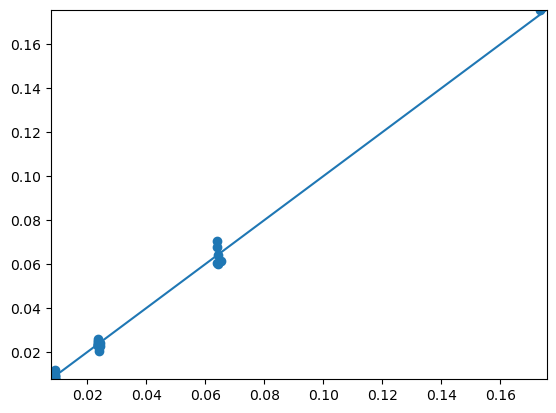

In [66]:
plt.scatter(normalized_RPS_post_exact, normalized_RPS_post) 
x=np.array(normalized_RPS_post_exact)
y=np.array(normalized_RPS_post)
lims = [
    min(x.min(), y.min()),
    max(x.max(), y.max()),
]
plt.plot(lims, lims)   # y = x
plt.xlim(lims)
plt.ylim(lims)

In [34]:
data_generating_partition = []

data_generating_partition.append(AIS.ProfilePart(cov_ids = tuple((0,0)), B = sigma[0]))
data_generating_partition.append(AIS.ProfilePart(cov_ids = tuple((0,1)), B = sigma[1]))
data_generating_partition.append(AIS.ProfilePart(cov_ids = tuple((1,0)), B = sigma[2]))
data_generating_partition.append(AIS.ProfilePart(cov_ids = tuple((1,1)), B = sigma[3]))

In [19]:
for partition in RPS_states:
    if AIS.states_equal(partition, data_generating_partition):
        print("yes")
        signature = AIS.state_signature(partition)
        idx = sig.index(signature)
        print(norm_true_post[idx])


yes
0.014832993449601315


In [30]:
indices = [index for index, value in enumerate(norm_true_post) if value > 0.02]

In [32]:
indices

[63]

In [33]:
losses[63][1]

4.375605647248442

In [34]:
for partition in losses:
    if AIS.states_equal(partition[0], data_generating_partition):
        print(partition[1])

4.7497993892940045


In [36]:
losses[63][0][0].B
print(losses[63][0][1].B)
print(losses[63][0][2].B)
print(losses[63][0][3].B)

[[1.]]
[[1. 1.]]
[[ 1.  1.]
 [ 1. inf]]


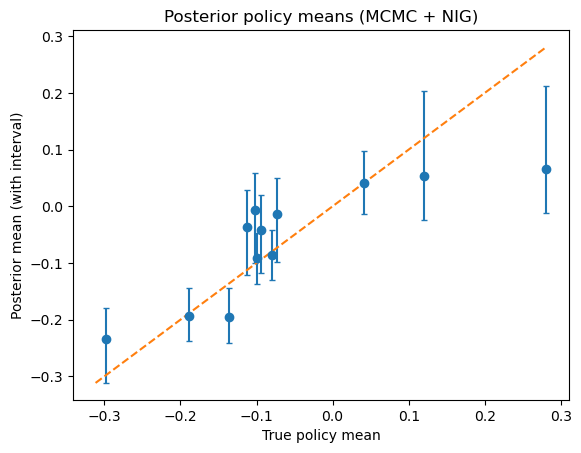

In [10]:
# 1) sample policy-mean draws from MCMC posterior using NIG pool posteriors
draws = MCMC.policy_mean_draws_from_mcmc_nig(
    mcmc_res=mcmc_res,
    D=D, y=y,
    policies=all_policies,
    prof_idx_of_policy=prof_idx_of_policy,
    R_per=R,
    M=M,
    lattice_edges=None,
    n_draws_per_state=1,
    mu0=0.0, kappa0=1.0, alpha0=0.0, beta0=-1.0,
    seed=1
)

# 2) summarize and plot spread vs data-gen truth
summ = MCMC.summarize_policy_draws(draws, qs=(0.1, 0.5, 0.9))
MCMC.plot_policy_spread(policy_means, summ, q_low=0.1, q_high=0.9)


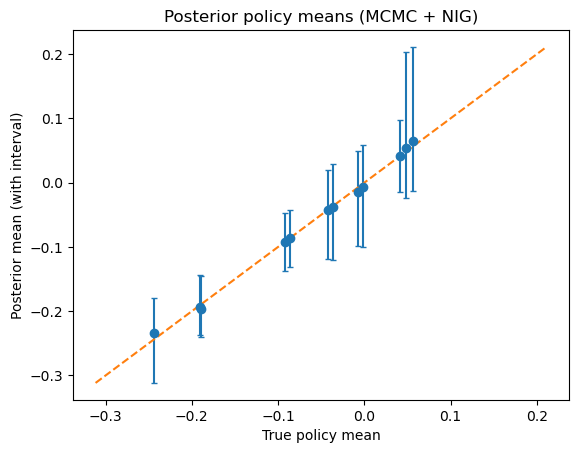

In [32]:
mu_hat_df = np.array([[i for i in mu_hat], [1 for i in mu_hat]]).transpose()
MCMC.plot_policy_spread(mu_hat_df, summ, q_low=0.1, q_high=0.9)

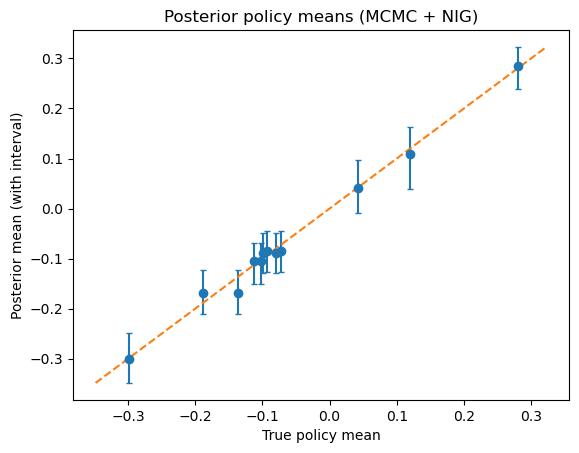

In [41]:
dat_gen_draws = MCMC.policy_mean_draws_from_mcmc_nig(
    mcmc_res={"samples": [data_generating_partition]},
    D=D, y=y,
    policies=all_policies,
    prof_idx_of_policy=prof_idx_of_policy,
    R_per=R,
    M=M,
    lattice_edges=None,
    n_draws_per_state=100,
    mu0=0.0, kappa0=1.0, alpha0=0.0, beta0=-1.0,
    seed=1
)

# 2) summarize and plot spread vs data-gen truth
dat_gen_summ = MCMC.summarize_policy_draws(dat_gen_draws, qs=(0.1, 0.5, 0.9))
MCMC.plot_policy_spread(policy_means, dat_gen_summ, q_low=0.1, q_high=0.9)

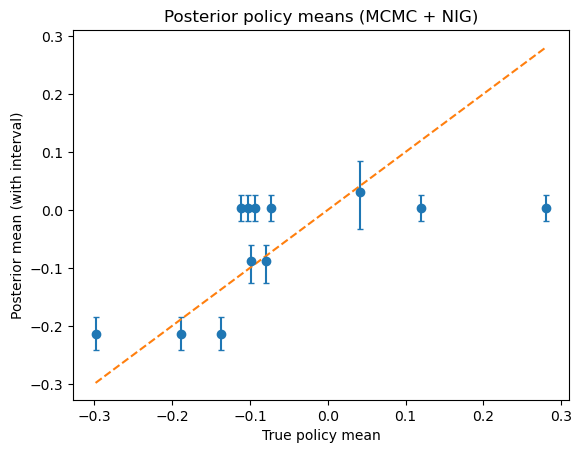

In [46]:
naive_draws = MCMC.policy_mean_draws_from_mcmc_nig(
    mcmc_res={"samples": [losses[63][0]]},
    D=D, y=y,
    policies=all_policies,
    prof_idx_of_policy=prof_idx_of_policy,
    R_per=R,
    M=M,
    lattice_edges=None,
    n_draws_per_state=100,
    mu0=0.0, kappa0=1.0, alpha0=0.0, beta0=-1.0,
    seed=1
)

# 2) summarize and plot spread vs data-gen truth
naive_summ = MCMC.summarize_policy_draws(naive_draws, qs=(0.1, 0.5, 0.9))
MCMC.plot_policy_spread(policy_means, naive_summ, q_low=0.1, q_high=0.9)

In [44]:
losses[63][0]
